# Case study: HiChIP + ATAC → super-enhancers, prime hubs and a shareable view

Columnar prototype (`genomeblocks.columnar`, branch `columnar-prototype`).

```
chrom sizes ─▶ Genome
ATAC peaks ─▶ CREs        GTF/GFF3 + ATAC bw ─▶ Genes (isoform-fixed)
HiChIP bedpe + mcool ─▶ Architecture ─▶ O/E · genes · prime hubs
HiChIP allValidPairs ─▶ short-range ends ─▶ MACS3 peaks + coverage bigWig ─▶ SEs
                     ─▶ shared / SE-only / prime-only genes ─▶ View (one HTML)
```

This notebook runs on **synthetic hg38-shaped stand-ins**. The first code cell lists the mESC (mm10) paths; swap them in to run it on real data.

In [1]:
import os, shutil, sys, time, warnings
from contextlib import contextmanager
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", message=".*(cairo|draw module|default behavior of `values`).*")

import genomeblocks.columnar as gbc
from genomeblocks.columnar import hichip
from genomeblocks.columnar.se import call_se, nearest_gene_within
from genomeblocks.columnar.view import View

@contextmanager
def timer(label):
    t = time.perf_counter(); yield
    print(f"⏱  {label}: {time.perf_counter() - t:,.1f} s")

# ── your files (mESC, mm10) ─────────────────────────────────────────────────
# CS       = "/groups/lackgrp/genome_annotations/mm10/mm10.chrom.sizes"
# ATAC_BED = ".../mm10-atac/results/bwa/merged_replicate/macs2/narrow_peak/C57BL6_ESC_GSE113431.mRp.clN_peaks.narrowPeak"
# ATAC_BW  = ".../mm10-atac/results/bwa/merged_replicate/bigwig/C57BL6_ESC_GSE113431.mRp.clN.bigWig"
# BEDPE    = ".../mm10-hichip/results_mm10/loops/MouseESC-mESC-HiChIP-H3K27ac.bedpe"
# MCOOL    = ".../mm10-hichip/results_mm10/cool/MouseESC-mESC-HiChIP-H3K27ac_b5000.mcool"
# AVP      = ".../mm10-hichip/results_mm10/allvalidpairs/MouseESC-mESC-HiChIP-H3K27ac.allValidPairs"
# GTF      = "/groups/lackgrp/genome_annotations/mm10/gencode.vM25.protein_coding.annotation.gtf"
# GSIZE    = "mm"
# ── synthetic stand-ins (what this notebook ran on) ─────────────────────────
D = "../../benchmarks/data/"
CS, ATAC_BED, ATAC_BW = D + "hg38.chrom.sizes", D + "peaks_A_100000.bed", D + "signal_0.bw"
BEDPE, MCOOL, AVP, GTF, GSIZE = D + "loops.bedpe", D + "hic_5kb.mcool", D + "hichip.allValidPairs", D + "genes.gtf", "hs"

RES, STITCH, W, MAXD, QHIC = 5000, 12_500, 5000, 50_000, 10
WORK = "work"; os.makedirs(WORK, exist_ok=True)
MACS3 = shutil.which("macs3") or os.path.join(os.path.dirname(sys.executable), "macs3")
PR_COL, SE_COL = "#DA0000", "#FF6600"

## 1 · Genome
One chromosome table that every other table shares, so codes match everywhere.

In [2]:
genome = gbc.set_default_genome(gbc.Genome.from_sizes(CS, name="mm10 (here: synthetic hg38)"))
sizes = {c: genome.size(c) for c in genome.names}
genome

Genome(mm10 (here: synthetic hg38) · 23 chroms: chr1, chr2, chr3, chr4, chr5, ...)

## 2 · CREs from ATAC peaks

In [3]:
with timer("Loci.make"):
    cre = gbc.Loci.make(ATAC_BED)
cre

⏱  Loci.make: 0.1 s


row,chrom,start,end,strand
0,chr1,"78,323","78,558",.
1,chr1,"97,098","97,696",.
2,chr1,"103,631","104,116",.
3,chr1,"145,482","145,774",.
4,chr1,"382,254","382,609",.
⋮,⋮,⋮,⋮,⋮
99997,chrX,"155,852,328","155,852,761",.
99998,chrX,"155,967,164","155,967,471",.
99999,chrX,"155,978,639","155,978,904",.


## 3 · Genes, isoform-fixed

`cre=` and `bw=` run `select_isoforms`, the same rule as the classic code. A TSS window (± `W`) must overlap an ATAC peak and reach `min_frac` of the best TSS signal in its gene. Each gene then follows its longest supported isoform.

In [4]:
with timer("Genes.make + select_isoforms"):
    genes = gbc.Genes.make(GTF, promoter_r=2500, cre=cre, bw=[ATAC_BW], r=W,
                           kw={"min_frac": 0.5, "rank": "longest", "verbose": True})
plain = gbc.Genes.make(GTF)
tss = lambda G: np.where(G.genes.strands == 2, G.genes.ends, G.genes.starts)
moved = np.abs(tss(genes) - tss(plain))
print(f"{(moved > 0).sum():,} of {len(genes):,} genes moved their TSS onto an ATAC-supported isoform "
      f"(median shift {np.median(moved[moved > 0]) / 1e3:.1f} kb)")
g = genes[int(np.argmax(moved))]
print(g, "· canonical:", g.canonical)
genes

[INFO] Isoform support: 6495/20000 genes with an open TSS (14913/70028 isoforms), 13505 fell back to the longest isoform.
⏱  Genes.make + select_isoforms: 2.8 s


2,179 of 20,000 genes moved their TSS onto an ATAC-supported isoform (median shift 8.3 kb)
Gene(GENE6969, chr5:25,222,147-25,676,125(+), protein_coding) · canonical: ENST00000696901.1


genes,"20,000 rows (gene_id, gene_name, gene_type)"
transcripts,"70,028 rows (transcript_id, gene → genes row)"
features,"491,201 exons · 211,471 CDS · 84,246 UTR (kind, transcript → transcripts row)"
coordinates,18.4 MB of arrays
annotation index,built on first use


## 4 · Architecture: loops → Hi-C weights → O/E → genes → prime hubs

In [5]:
with timer("make → add_mcool → normalize → annotate → strength"):
    A = (gbc.Architecture.make(cre, BEDPE, verbose=False)
           .add_mcool(MCOOL, resolution=RES, verbose=False)
           .normalize(verbose=False)
           .annotate(genes, key="n", name="gene_n", verbose=False)
           .strength(verbose=False))
hubs = A.prime_hubs("n", gene="gene_n", verbose=False)
HUB = np.isin(cre.uid, hubs["hub_uids"])
print(f"{int(HUB.sum()):,} prime CREs ({len(hubs['prime_genes']):,} prime genes by vertex label)")
A

⏱  make → add_mcool → normalize → annotate → strength: 1.1 s


7,947 prime CREs (458 prime genes by vertex label)


block,edge rows,edges
chr1,"0–9,479","9,479"
chr2,"9,479–18,891","9,412"
chr3,"18,891–26,259","7,368"
chr4,"26,259–32,772","6,513"
⋮,,
chr22,"105,791–107,730","1,939"
chrX,"107,730–114,367","6,637"
trans,"114,367–114,367",0


## 5 · HiChIP short-range track, inside genomeblocks

This replaces steps 1 and 3 of `make_tracks.sh`: cis pairs ≤ 1 kb → both 5′ ends → 147 bp fragments → coverage bigWig. On the benchmark file the output is identical to awk | sort | `bedtools genomecov`, and it is faster. Step 2 (peak calling) stays with MACS3.

In [6]:
with timer("allValidPairs → short-range 5' ends"):
    ends = hichip.shortrange_ends(AVP, max_dist=1000)
print(f"{len(ends):,} ends")
with timer("MACS3 on the ends"):
    np_path = hichip.macs3(hichip.write_bed(ends, f"{WORK}/sr1kb_ends.bed"), "sr1kb", f"{WORK}/peaks",
                           gsize=GSIZE, exe=MACS3)
with timer("fragments → coverage → bigWig"):
    K27_BW = hichip.to_bigwig(hichip.fragments(ends, 147, sizes), f"{WORK}/H3K27ac_HiChIP_shortrange.bw", sizes)

⏱  allValidPairs → short-range 5' ends: 3.6 s
5,095,496 ends


⏱  MACS3 on the ends: 31.9 s


⏱  fragments → coverage → bigWig: 9.8 s


## 6 · Super-enhancers (ROSE: stitch 12.5 kb · mean × width · slope-1 knee)

[INFO] 22,997 peaks → 19,025 stitched regions → 253 SEs (median 19,013 bp)
⏱  call_se: 0.5 s


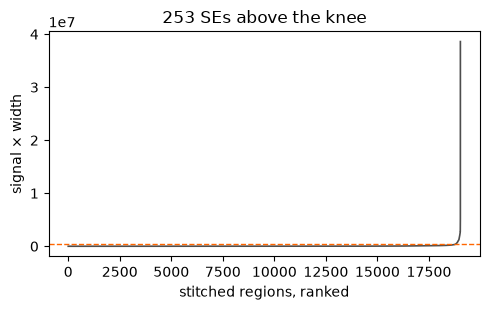

In [7]:
p = pd.read_table(np_path, header=None)
peaks = gbc.Loci.from_frame(p[p[8] >= QHIC])                     # q-value filter, as in your notebook
with timer("call_se"):
    SE = call_se(peaks, [K27_BW], stitch=STITCH, workers=4, verbose=True)

allr = SE.all_regions
y = np.sort(allr.cols["score"])
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(np.arange(len(y)), y, color="0.3", lw=1.2)
ax.axhline(y[len(y) - len(SE)], color=SE_COL, lw=1, ls="--")
ax.set(xlabel="stitched regions, ranked", ylabel="signal × width", title=f"{len(SE):,} SEs above the knee")
plt.tight_layout()

## 7 · Prime genes, SE genes and their overlap

In [8]:
FOOT = A.support(genes, r=W, mode="center", rows=True)          # gene -> anchor CRE rows (TSS ± 5 kb, centre)
U = set(FOOT)
PRIME = {g for g, rows in FOOT.items() if HUB[rows].any()}

G = genes.genes                                                    # one TSS per universe gene, like your TSSP
names = G.cols["gene_name"].astype(str)
first = pd.Series(np.arange(len(G))).groupby(names).first()
uni = first[first.index.isin(U)].to_numpy()
tss_pos = np.where(G.strands[uni] == 2, G.ends[uni] - 1, G.starts[uni])
TSS = gbc.Loci(G.codes[uni], tss_pos, tss_pos + 1, genome=G.genome, cols={"gene": names[uni]})
hit = nearest_gene_within(SE, TSS, MAXD)
SEG = set(TSS.cols["gene"][hit[hit >= 0]])
SETS = {"shared": PRIME & SEG, "SE only": SEG - PRIME, "prime only": PRIME - SEG}

indptr, nbr, eid = A._adj()                                        # anchor budget: Σ O/E from anchor to partners
def budget(rows):
    rs = set(rows.tolist())
    e = [eid[k] for v in rows for k in range(indptr[v], indptr[v + 1]) if nbr[k] not in rs]
    n = A.ep.n[e] if e else np.zeros(0)
    return float(n[n > 0].sum())
BUD = pd.Series({g: budget(rows) for g, rows in FOOT.items()})

print(f"{len(cre):,} CREs ({A.n_loci:,} in the network), {int(HUB.sum()):,} prime CREs; {len(SE):,} SEs "
      f"({int(np.median(SE.lengths)):,} bp median), {int(cre.overlap_any(SE).sum()):,} CREs inside; "
      f"{len(U):,} genes with an anchor CRE, {len(PRIME):,} prime genes, {len(SEG):,} SE genes")
pd.DataFrame({k: [len(v), BUD.reindex(list(v)).median()] for k, v in SETS.items()},
             index=["genes", "median anchor budget (Σ O/E)"]).round(1)

100,000 CREs (73,237 in the network), 7,947 prime CREs; 253 SEs (19,013 bp median), 1,465 CREs inside; 4,388 genes with an anchor CRE, 303 prime genes, 96 SE genes


,shared,SE only,prime only
genes,15.0,81.0,288.0
median anchor budget (Σ O/E),1.6,0.0,1.7


## 8 · The view: one HTML file to share

Tracks are added like a figure. Regions are one-click buttons: the top shared, SE-only and prime-only genes by anchor budget. The reader can search any gene, click any CRE, and open trans partners side by side.

In [9]:
v = View(A, genes=genes, samples={"mESC": "#46a8e4"}, chrom_sizes=sizes, anchor_r=W, anchor_mode="center",
         gene_half=500_000, title="mESC CRE Hubs",
         subtitle="H3K27ac HiChIP + ATAC (synthetic stand-in data). Search a gene, click a CRE to see its partners.")
v.anchor_profile("graph O/E (anchor)")
v.cre_values("node strength", {"mESC": A.vp.strength})
v.signal("ATAC", {"mESC": ATAC_BW})
v.signal("H3K27ac HiChIP (short-range)", {"mESC": K27_BW})
v.intervals("SE", {"SE (HiChIP short-range)": SE}, color=SE_COL)
v.intervals("prime hubs", {"prime CREs": HUB}, color=PR_COL)
v.cres("CREs (anchor yellow · partners black/grey)")
v.loops({"mESC": "n"})
v.genes()
for kind, gs in SETS.items():
    for g in BUD.reindex(list(gs)).sort_values(ascending=False).index[:3]:
        v.region(g, gene=g, note=f"{kind} · anchor Σ O/E {BUD[g]:.1f}")
v.hubs(A.vp.strength, label="strength")
with timer("View.save"):
    parts = v.save(f"{WORK}/mesc_view.html")
pd.Series({k: f"{b / 1e6:.2f} MB" for k, b in parts.items()}).to_frame("embedded")

⏱  View.save: 0.9 s


,embedded
CREs,0.66 MB
edges,0.24 MB
genes,1.31 MB
track: node strength,0.05 MB
track: ATAC,0.83 MB
track: H3K27ac HiChIP (short-range),0.19 MB
track: SE,0.00 MB
track: prime hubs,0.05 MB
viewer (js + css),0.04 MB
total,3.41 MB


## On your cluster

1. Swap the paths in the first code cell for the mESC files and set `GSIZE = "mm"`.
2. Run top to bottom. The short-range step reads the allValidPairs once; peak calling is still MACS3.
3. Send `work/mesc_view.html` to anyone. It opens in a browser with no install, and all data is inside the file.